# Лабоаторная работа 2
## Линейная регрессия

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1.** Загрузите датасет с успеваемостью студентов (https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

   Изучите признаки: их шкалу, тип данных, наличие пропусков, распределение. Нашей целевой переменной будет последняя колонка - Performance Index

In [33]:
data = pd.read_csv('Student_Performance.csv')
print("=" * 60)
print(data.info())
print("=" * 60)
print(data.describe())
print("=" * 60)
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Переведите все фичи в числа и сохраните в переменной Х формата np.array. Целевую колонку сохраните в массив y. Для превращения в массив можно использовать df.values. Постройте корреляционную матрицу (это можно сделать как за счет numpy, так и с исходным датафреймом, если выделить из него только числовые колонки)

Разбейте данные на тренировочный и тестовый наборы в отношении 80:20

In [34]:

# перевел все фичи в числа
data['Extracurricular Activities'] = data['Extracurricular Activities'].apply(lambda x: 1 if x == 'Yes' else 0)

X = data.drop('Performance Index', axis=1).values
y = data['Performance Index'].values

numeric_data = data.drop('Performance Index', axis=1)
correction_matrix = numeric_data.corr()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)


Размер X_train: (8000, 5)
Размер X_test: (2000, 5)
Размер y_train: (8000,)
Размер y_test: (2000,)


**2.** На основе базовых классов из sklearn напишите свою линейную регрессию, где коэффициенты находятся с помощью псевдообратной матрицы. Не забудьте про свободный член! Он должен откуда-то появиться.
   $$ w = (X^TX)^{-1} X^T y$$

Второй регрессор напишите с градиентным спуском (мы тут не будем рассматривать стохастический и мини-батч, хотя, если интересно, можете и их заимплементить). Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. По результатам измышлений допишите еще входных параметров в метод \__init__. В качестве функции потерь выберем MSE. В матричной записи она будет выглядеть как $\frac{1}{N}(Xw - y)^T(Xw - y).$ Дифференцируя ее по $w$, получим $$\frac{2}{N} X^T(Xw - y).$$ Формула с псевдообратной матрицей, кстати, получается, если приравнять это к 0 и выразить $w$.

Мы хотим двигаться в направлении, противоположном этому, т.е. эта величина, умноженная на скорость обучения (learning rate), отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, он войдет в lr, а вот убирать $N$, пожалуй, не стоит.

In [35]:
from sklearn.base import BaseEstimator, RegressorMixin

In [77]:
# напишите свою линейную регрессию, 
# где коэффициенты находятся с помощью псевдообратной матрицы
class PseudoInvRegressor(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.weights_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X] # [X|1], учли w0
        # $$ w = (X^TX)^{-1} X^T y$$
        self.weights_ = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        predictions = X_with_bias @ self.weights_
        return predictions #вектор предсказаний

In [81]:
# Второй регрессор напишите с градиентным спуском
class GradRegressor(BaseEstimator, RegressorMixin):
    # Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. 
    # По результатам измышлений допишите еще входных параметров в метод \__init__
    def __init__(self, learning_rate=0.001, n_iterations=1000, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations # max количество итераций
        self.tolerance = tolerance
        self.weights_ = None
        self.loss_history_ = []
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        
        self.weights_ = np.random.randn(n_features)
        
        prev_loss = float('inf')
        
        for i in range(self.n_iterations): 
            # предсказание
            predications = X_with_bias @ self.weights_
            
            # считаем ошибку
            # $\frac{1}{N}(Xw - y)^T(Xw - y).$
            loss = np.mean((predications - y)**2)
            self.loss_history_.append(loss)
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Остановка на {i+1}")
                break
            prev_loss = loss
            
            #  $$\frac{2}{N} X^T(Xw - y).$$ 
            gradient = (2 / n_samples) * X_with_bias.T @ (predications - y)
            # обновляем веса
            
            # Мы хотим двигаться в направлении, противоположном этому, 
            #т.е. эта величина, умноженная на скорость обучения (learning rate),
            # отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, 
            # он войдет в lr, а вот убирать $N$, пожалуй, не стоит.
            self.weights_ = self.weights_ - self.learning_rate * gradient
            
            if (i % 5 == 0):
                print(f"{i}: MSE = {loss}")
            
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_ #вектор предсказаний

Обучите оба регрессора на загруженных данных. Для второго регрессора придется поэкспериментировать со скоростью и продолжительностью обучения. Постройте график ошибок. 

MSE для PseudoInvRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]
0: MSE = 11663.440513498992
5: MSE = 111.96090386924571
MSE для GradRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]


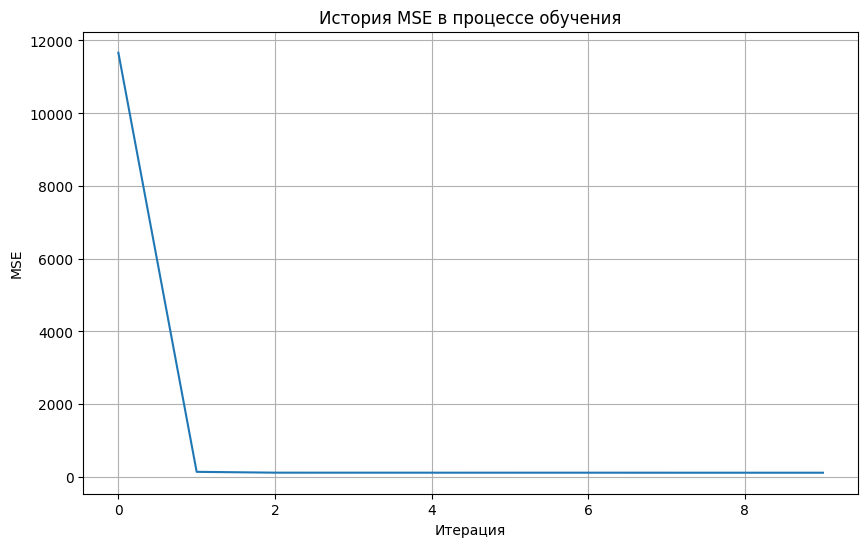

In [88]:
# Обучите оба регрессора на загруженных данных
pseudo_model = PseudoInvRegressor()
pseudo_model.fit(X_train, y_train)
pseudo_preds = pseudo_model.predict(X_test)
pseudo_mse = np.mean((pseudo_preds - y_test)**2)
print(f"MSE для PseudoInvRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)


grad_model = GradRegressor(
    # Для второго регрессора придется поэкспериментировать 
    learning_rate=0.0001, # со скоростью и  
    n_iterations=10) # продолжительностью обучения
grad_model.fit(X_train, y_train)
grad_preds = grad_model.predict(X_test)
grad_mse = np.mean((grad_preds - y_test)**2)
print(f"MSE для GradRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)

# Постройте график ошибок. 
plt.figure(figsize=(10, 6))
plt.plot(grad_model.loss_history_)
plt.title("История MSE в процессе обучения")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

**3.** Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров. Для этого воспользуйтесь скейлерами из sklearn. Метод fit_transform позволяет сразу и настроить параметры скейлера и выполнить масштабирование. **Внимание!** Обучать (fit) скейлер нужно только на тренировочных данных. А потом с полученными на них параметрами применять его к тестовым. **Еще внимание!** Если в вашей матрице $X$ был столбик для свободного члена, после масштабирования он станет нулевым. Это не то, чего нам бы хотелось, это надо пофиксить

Итак, что изменилось?

Контрольные вопросы: зачем масштабировать данные? Когда это обязательно, когда не очень? Надо ли масштабировать $y$? Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?

MSE для псевдообратного регрессора (scaled): 4.0826
0: MSE = 3375.426624720619
5: MSE = 2759.034110602204
10: MSE = 2255.344645389981
15: MSE = 1843.7506689988934
20: MSE = 1507.412786159304
25: MSE = 1232.5707248517238
30: MSE = 1007.9802954483789
35: MSE = 824.4533089744269
40: MSE = 674.4816266003263
45: MSE = 551.9299555807346
50: MSE = 451.7848202932964
55: MSE = 369.9494359574603
60: MSE = 303.0760911234013
65: MSE = 248.42918000011082
70: MSE = 203.77327996433277
75: MSE = 167.28169449329175
80: MSE = 137.4617192407896
85: MSE = 113.0935733036518
90: MSE = 93.18049691084933
95: MSE = 76.90797369603955
100: MSE = 63.61040908579409
105: MSE = 52.74390143054817
110: MSE = 43.863991809139016
115: MSE = 36.607482153129375
120: MSE = 30.677577800636644
125: MSE = 25.831746613230578
130: MSE = 21.871797940007973
135: MSE = 18.63577553865339
140: MSE = 15.991332780828825
145: MSE = 13.830319115614799
150: MSE = 12.064356321593197
155: MSE = 10.621223573351639
160: MSE = 9.44190343871110

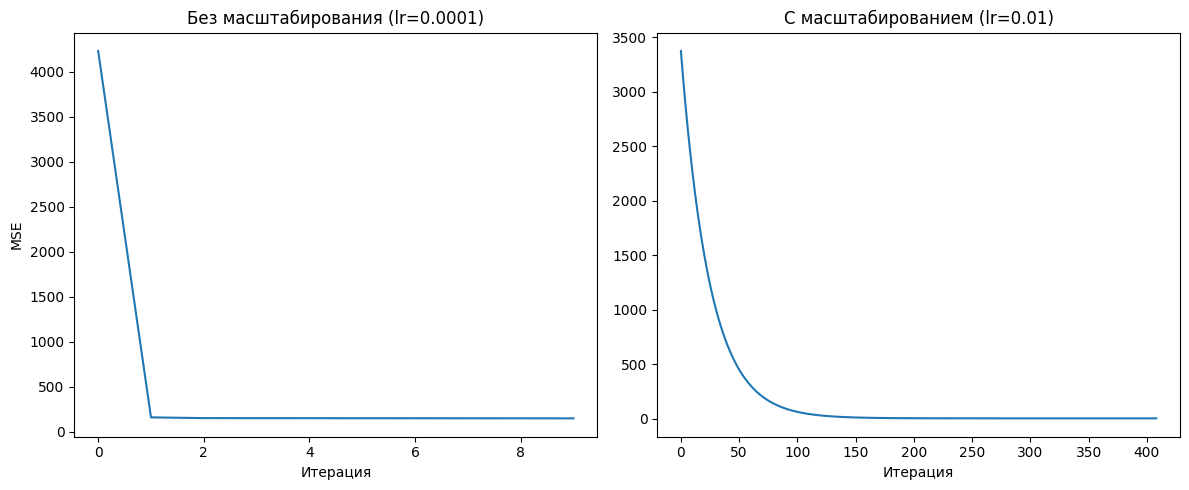

In [86]:
# Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров.

# Для этого воспользуйтесь скейлерами из sklearn.
# на ваш выбор
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()

# Метод fit_transform позволяет сразу 
# и настроить параметры скейлера и выполнить масштабирование
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pseudo_model_scaled = PseudoInvRegressor()
pseudo_model_scaled.fit(X_train_scaled, y_train)
pseudo_preds_scaled = pseudo_model_scaled.predict(X_test_scaled)
pseudo_mse_scaled = np.mean((pseudo_preds_scaled - y_test)**2)
print(f"MSE для псевдообратного регрессора (scaled): {pseudo_mse_scaled:.4f}")

grad_model_scaled = GradRegressor(
    learning_rate=0.01, 
    n_iterations=1000)
grad_model_scaled.fit(X_train_scaled, y_train)
grad_preds_scaled = grad_model_scaled.predict(X_test_scaled)
grad_mse_scaled = np.mean((grad_preds_scaled - y_test)**2)
print(f"MSE для градиентного регрессора (scaled): {grad_mse_scaled:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(grad_model.loss_history_)
plt.title("Без масштабирования (lr=0.0001)")
plt.xlabel("Итерация"); plt.ylabel("MSE")

plt.subplot(1, 2, 2)
plt.plot(grad_model_scaled.loss_history_)
plt.title("С масштабированием (lr=0.01)")
plt.xlabel("Итерация")
plt.tight_layout()
plt.show()



= Итак, что изменилось?
из явного 
- изменился график, он стал гладким.
- можно увеличить шаг lt. в данном прогоне он у меня в 100 раз больше (0.01), чем я использовал в Без масштабирования (с таким шагом для данных Без масштабирования MSE уходили в бесконечность)
- Градиентом получилось найти даже более оптимальное решение. более точное, чем аналитическим решением (по всей видимости это связано с вычислениями чисел с плавающей точкой)

Контрольные вопросы: 

= Зачем масштабировать данные? Когда это обязательно, когда не очень?
- Масштабирование данных, это процесс приведения признаков к "подобному" виду. к примеру -- два параметра, один от 1 до 10, другой от 1 до 100. Изменение на 1 одного и другого -- это 10% и 1% соответственно. то есть, один из параметров может считаться более "важным" (разные веса признаков). и чтобы этого избежать, занимаются масштабированием данных. 
- это особенно может быть проблемой для тех, кто использует работу с градиентами -- шаги вдоль признаков могут быть большими/маленькими из-за проблемы с их масштабом. и регуляризацией тоже.
- если же такой нужды в масштабе нет (например, категории тд), то и масштабировать не нужно

= Надо ли масштабировать $y$? 
- технически нет, ведь: если посмотреть на уравнение $y = X*w + w_0$, то если промасштабировать $X$, то измениться и матрица весов $w$ (модель найдет его другой), и в результате будет все равно получиться тот же $y$.

= Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?
- ассимтотическая сложность вычисления псевдообратной O(количество признаков^3) и O(количество признаков^2) памяти. А градиентные методы просят перемножение матрицы и вектора, что занимает O(n) / O(n log n)
- когда данные "доходят", то придется пересчитывать псевдообратную (либо каждый раз, либо "реже"). а градиентный способ позволяет обновлять постепенно
- из-за плохой обусловленности вычисление псевдообратной может быть неустойчивым 

**4.** Добавим возможность l1 и l2 регуляризации. Это означает, что функция потерь примет вид

$$\frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

где $\lambda_1$, $\lambda_2$ отвечают за выраженность l1 и l2 регуляризаций и могут их выключить, будучи равными 0.

Здесь мы сталкиваемся с проблемой в случае псевдообратного решения - из-за того, что модуль недифференцируем в 0, мы, вообще-то, не можем получить одну конечную формулу для решения. Но для l2 все в порядке. 

Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации. Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная. Добавьте в класс этого регрессора l2-регуляризацию.

Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).

**5.** Обучите ваши регрессоры с этими новыми настройками. Рассмотрите 3 случая: 
- псевдообратные регрессор с l2
- градиентный регрессор с l1
- градиентный регрессор с l2

Подберите какие-то лямбды, дающие адекватный результат. Потом загрузите регрессоры из sklearn и обучите их с теми же (насколько это возможно) настройками. Сравните полученные веса и ошибку на тренировочном и тестовых множествах (выведите их куда-нибудь в одно место, вместе с параметрами, чтоб красиво. Можно, например, собрать из них маленький датафрейм)

Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.

Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?

In [40]:
from sklearn.linear_model import Lasso, Ridge

**6.** Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. Обучите два регрессора - один с абсолютной ошибкой, другой с квадратичной. Сравните веса, значения обеих ошибок на тренировочном и тестовом наборах

**7.** В датасете со студентами у нас был нормально распределенный таргет. Вообще-то это как бы не обязательно (нормальному распределению должны следовать ошибки; да и это тоже необязательно - смотря какие выводы вы хотите потом сделать о модели), но в некоторых туториалах можно встретить и такое требование. А еще в некоторых - требование нормального распределения фичей. Математического пояснения этому обычно не дается, а говорится что-то вроде "модель эффективнее обучается на нормально распределенных данных". 

Загрузите датасет с ценами медстраховки (https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset ). Масштабируйте данные, предобработайте категориальные признаки. Попробуйте скорректировать а) распределение целевой переменной б) распределения не бинарных фичей до нормального. На этих данных обучите модели настолько хорошо, насколько сможете, и сравните их качество с моделями без подобных преобразований. Сравнивать будем по MSE на тесте (20%), при этом если вы преобразовали целевую переменную, не забудьте преобразовать ее обратно прежде чем вычислять эту MSE для сравнения

**Внимание!** Корректировка распределения проводится по тренировочным данным. По ним вы определяете некое преобразование, которое потом будет применяться на тест

**8.** Добавим в наши данные немного мусора. Сделайте колонку с id пациента (числа от 0 до ...) и его любимым цветом (случайный цвет, заданный тремя параметрами RGB, распределение случайных величин - на ваше усмотрение). Проведите предобработку данных, которую посчитаете нужной, только не выбрасывайте наши мусорные колонки. Чтобы поменьше заниматься подбором параметров, обучим следующием модели:

- псевдообратный регрессор
- псевдообратный регрессор с L2 регуляризацией
- псевдообратный регрессор, но мы выбросили id
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили id
- псевдообратный регрессов, но мы выбросили и id, и цвета
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили и id, и цвета

Вычислите для каждой модели $R^2$ и скорректированный $R^2$ на тестовом и на тренировочном множествах, сведите в табличку. Какие выводы можно сделать из увиденного? 